In [8]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_style("whitegrid")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df = pd.read_csv("C:/internship/datasets/processed/diabetic_data_base_table.csv")


C:\Users\shrey\AppData\Local\Temp\ipykernel_6272\2389403848.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/internship/datasets/processed/diabetic_data_base_table.csv")


In [10]:
df.shape


(101766, 51)

In [11]:
num_encounters = df["encounter_id"].nunique()
num_patients = df["patient_nbr"].nunique()

num_encounters, num_patients


(101766, 71518)

In [12]:
df.dtypes


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [13]:
target_counts = df["readmit_30"].value_counts().to_frame(name="count")
target_counts["percentage"] = (
    target_counts["count"] / len(df) * 100
)

target_counts


,count,percentage
readmit_30,,
0,90409,88.840084
1,11357,11.159916


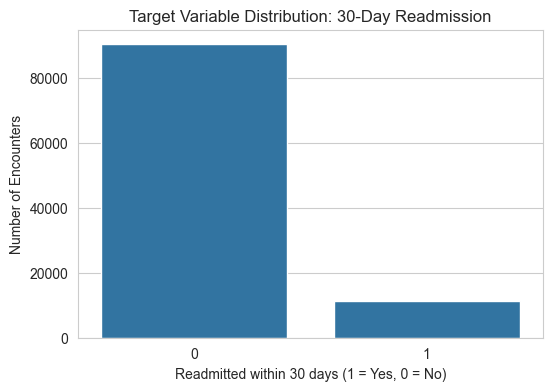

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts["count"]
)
plt.xlabel("Readmitted within 30 days (1 = Yes, 0 = No)")
plt.ylabel("Number of Encounters")
plt.title("Target Variable Distribution: 30-Day Readmission")
plt.show()


In [15]:
encounters_per_patient = (
    df.groupby("patient_nbr")["encounter_id"]
    .count()
    .rename("num_encounters")
)


In [16]:
encounters_per_patient.describe()


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: num_encounters, dtype: float64

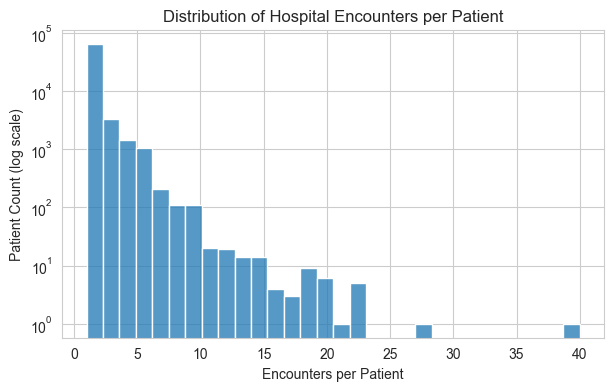

In [17]:
plt.figure(figsize=(7,4))
sns.histplot(encounters_per_patient, bins=30)
plt.yscale("log")
plt.xlabel("Encounters per Patient")
plt.ylabel("Patient Count (log scale)")
plt.title("Distribution of Hospital Encounters per Patient")
plt.show()


In [18]:
df["age"].value_counts().sort_index()


age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

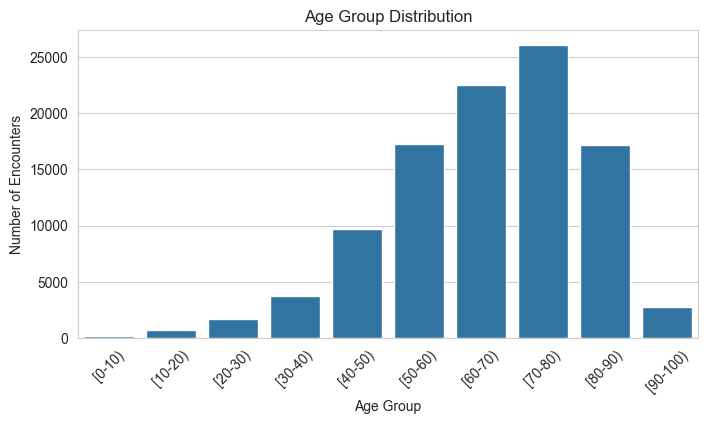

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x="age",
    order=sorted(df["age"].unique())
)
plt.xticks(rotation=45)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")
plt.show()


In [20]:
age_readmit_rate = (
    df.groupby("age")["readmit_30"]
    .mean()
    .sort_index()
)

age_readmit_rate


age
[0-10)      0.018634
[10-20)     0.057887
[20-30)     0.142426
[30-40)     0.112318
[40-50)     0.106040
[50-60)     0.096662
[60-70)     0.111284
[70-80)     0.117731
[80-90)     0.120835
[90-100)    0.110992
Name: readmit_30, dtype: float64

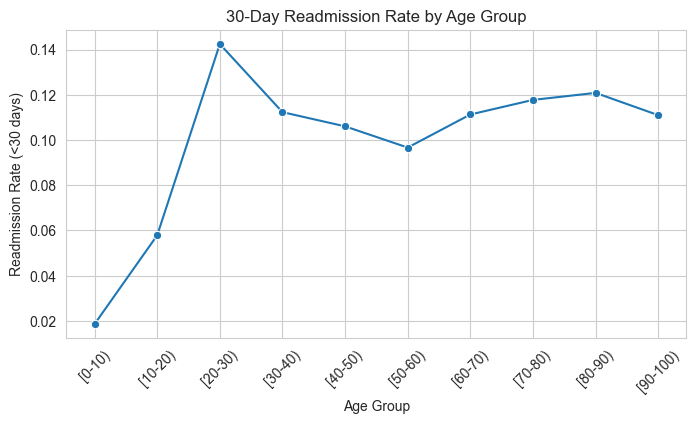

In [21]:
plt.figure(figsize=(8,4))
sns.lineplot(
    x=age_readmit_rate.index,
    y=age_readmit_rate.values,
    marker="o"
)
plt.xticks(rotation=45)
plt.ylabel("Readmission Rate (<30 days)")
plt.xlabel("Age Group")
plt.title("30-Day Readmission Rate by Age Group")
plt.show()


In [22]:
gender_readmit_rate = (
    df.groupby("gender")["readmit_30"]
    .mean()
)

gender_readmit_rate


gender
Female             0.112452
Male               0.110615
Unknown/Invalid    0.000000
Name: readmit_30, dtype: float64

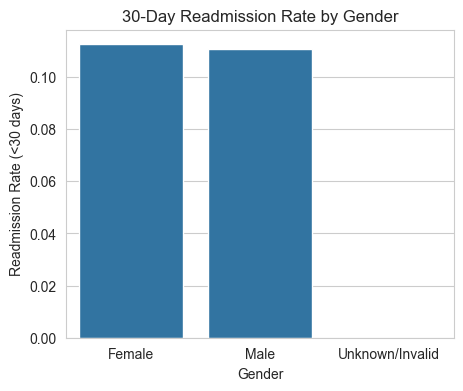

In [23]:
plt.figure(figsize=(5,4))
sns.barplot(
    x=gender_readmit_rate.index,
    y=gender_readmit_rate.values
)
plt.ylabel("Readmission Rate (<30 days)")
plt.xlabel("Gender")
plt.title("30-Day Readmission Rate by Gender")
plt.show()


In [24]:
df["time_in_hospital"].describe()


count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

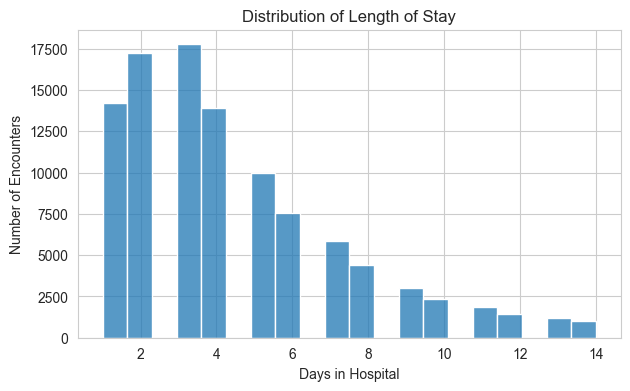

In [25]:
plt.figure(figsize=(7,4))
sns.histplot(df["time_in_hospital"], bins=20)
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Encounters")
plt.title("Distribution of Length of Stay")
plt.show()


In [26]:
df.groupby("readmit_30")["time_in_hospital"].describe()


,count,mean,std,min,25%,50%,75%,max
readmit_30,,,,,,,,
0,90409.0,4.349224,2.976382,1.0,2.0,4.0,6.0,14.0
1,11357.0,4.768249,3.028165,1.0,2.0,4.0,6.0,14.0


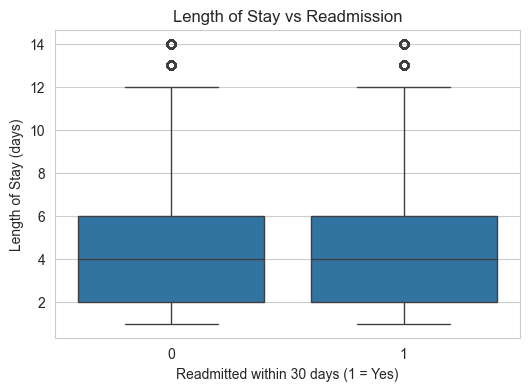

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x="readmit_30",
    y="time_in_hospital"
)
plt.xlabel("Readmitted within 30 days (1 = Yes)")
plt.ylabel("Length of Stay (days)")
plt.title("Length of Stay vs Readmission")
plt.show()


In [28]:
utilization_cols = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

df.groupby("readmit_30")[utilization_cols].describe()


number_inpatient                                                \
                      count      mean       std  min  25%  50%  75%   max   
readmit_30                                                                  
0                   90409.0  0.561648  1.125315  0.0  0.0  0.0  1.0  19.0   
1                   11357.0  1.224003  1.954577  0.0  0.0  0.0  2.0  21.0   

           number_emergency                                                \
                      count      mean       std  min  25%  50%  75%   max   
readmit_30                                                                  
0                   90409.0  0.177803  0.857353  0.0  0.0  0.0  0.0  76.0   
1                   11357.0  0.357313  1.370384  0.0  0.0  0.0  0.0  64.0   

           number_outpatient                                                
                       count      mean       std  min  25%  50%  75%   max  
readmit_30                                                                  
0                    90409.0  0.360871  1.262484  0.0  0.0  0.0  0.0  42.0  
1                    11357.0  0.436911  1.302788  0.0  0.0  0.0  0.0  40.0

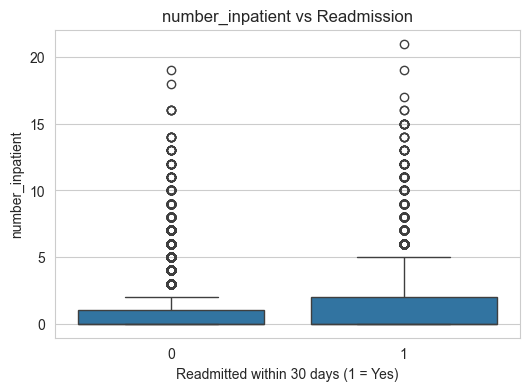

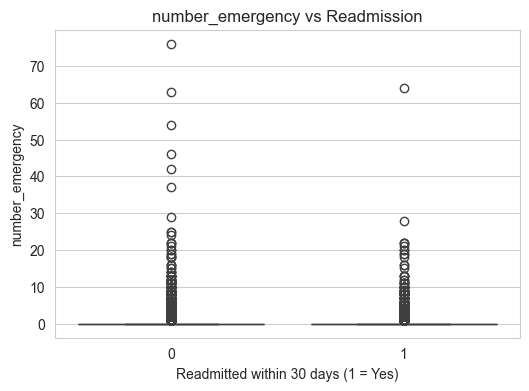

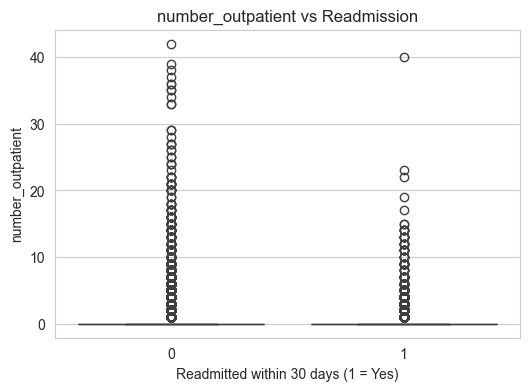

In [29]:
for col in utilization_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x="readmit_30",
        y=col
    )
    plt.title(f"{col} vs Readmission")
    plt.xlabel("Readmitted within 30 days (1 = Yes)")
    plt.ylabel(col)
    plt.show()


In [30]:
complexity_cols = [
    "num_medications",
    "num_lab_procedures"
]

df.groupby("readmit_30")[complexity_cols].describe()


num_medications                                                    \
                     count       mean       std  min   25%   50%   75%   max   
readmit_30                                                                     
0                  90409.0  15.911137  8.124725  1.0  10.0  15.0  20.0  79.0   
1                  11357.0  16.903143  8.096696  1.0  11.0  16.0  21.0  81.0   

           num_lab_procedures                                               \
                        count       mean        std  min   25%   50%   75%   
readmit_30                                                                   
0                     90409.0  42.953644  19.719348  1.0  31.0  44.0  57.0   
1                     11357.0  44.226028  19.276087  1.0  33.0  45.0  58.0   

                   
              max  
readmit_30         
0           129.0  
1           132.0

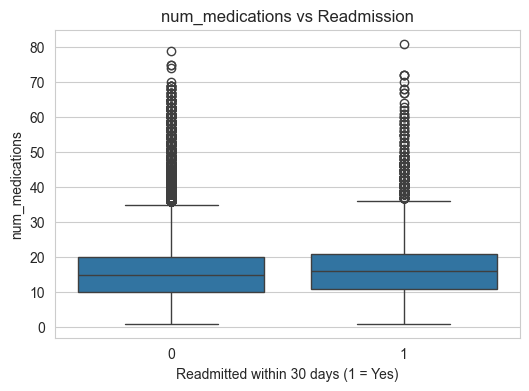

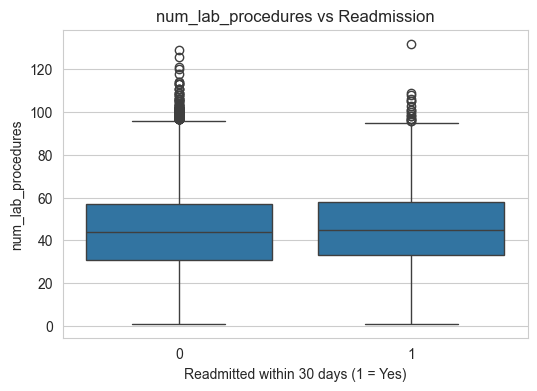

In [31]:
for col in complexity_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x="readmit_30",
        y=col
    )
    plt.title(f"{col} vs Readmission")
    plt.xlabel("Readmitted within 30 days (1 = Yes)")
    plt.ylabel(col)
    plt.show()
